# **CNN**

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [3]:
#Doc du lieu MNIST
mmist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mmist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [ ]:
num_classes = 10
input_shape = (28 , 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test  = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


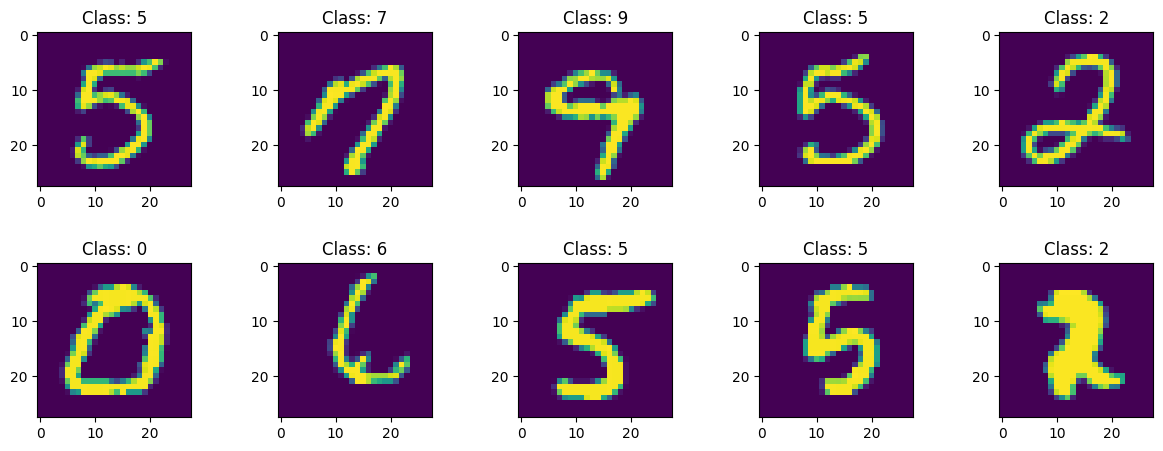

In [ ]:
#Truc quan hoa 10 anh dau tien
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class: '+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [ ]:
#Chuyen gia tri nhan thanh one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
#Xay dung mo hinh CNN
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Huan luyen mo hinh CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.8558 - loss: 0.5759 - val_accuracy: 0.9460 - val_loss: 0.1980
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9591 - loss: 0.1416 - val_accuracy: 0.9625 - val_loss: 0.1277
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9714 - loss: 0.0979 - val_accuracy: 0.9670 - val_loss: 0.1018
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9776 - loss: 0.0749 - val_accuracy: 0.9700 - val_loss: 0.0944
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.9801 - loss: 0.0617 - val_accuracy: 0.9730 - val_loss: 0.0848
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.9826 - loss: 0.0542 - val_accuracy: 0.9750 - val_loss: 0.0771
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9858 - loss: 0.0453 - val_accuracy: 0.9755 - val_loss: 0.0806
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9878 - loss: 0.0380 

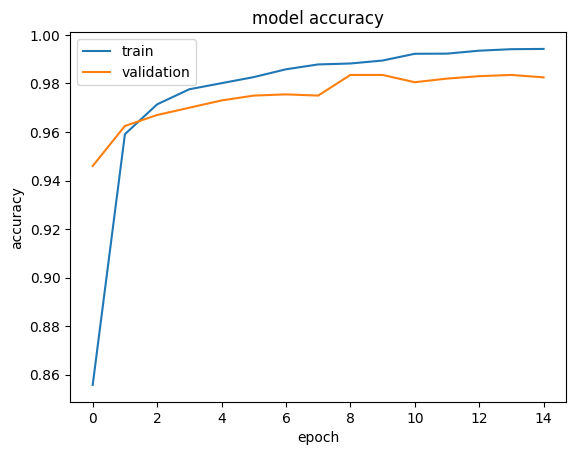

In [ ]:
#Danh gia mo hinh CNN
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

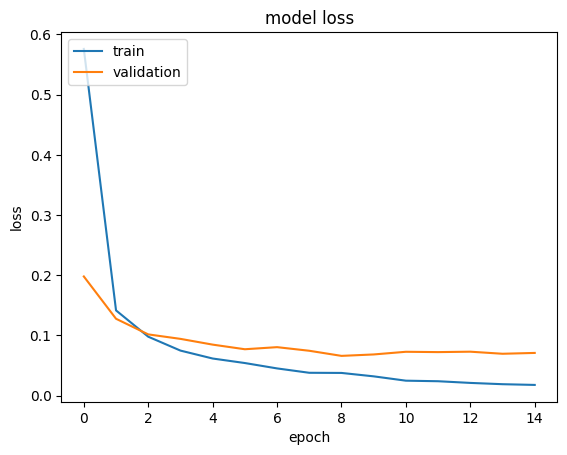

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
#Danh gia mo hinh CNN thu nghiem tren file test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss', score[0])
print('Test accuracy', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9837 - loss: 0.0559
Test loss 0.05593138188123703
Test accuracy 0.9836983680725098


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[4.4780700e-06 2.1792760e-03 9.9777383e-01 8.1228267e-11 8.7808903e-19
  4.7691482e-14 4.2314932e-05 2.4883022e-16 1.6071391e-08 5.4992130e-21]]
2 2


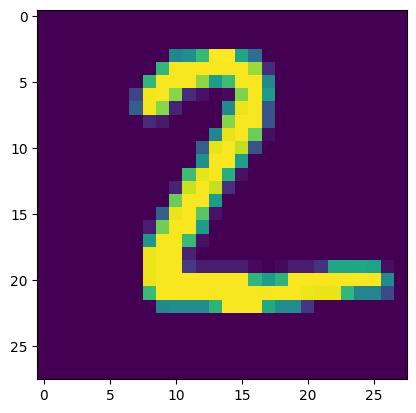

In [ ]:
#Du bao nhan cho anh su dung CNN
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [ ]:
#Luu tham so mo hinh CNN
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
[[1.92946274e-07 9.99928951e-01 1.41336363e-06 2.63050470e-08
  4.04532875e-05 1.40343355e-08 4.17838282e-06 9.44823569e-06
  1.53540423e-05 1.40011016e-08]]
1 1


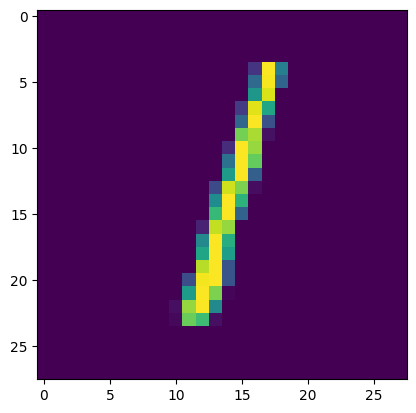

In [ ]:
#Nap lai mo hinh va tham so
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

#**Bài Tập 1**

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Kích thước X_train ban đầu: (50000, 32, 32, 3)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 132ms/step - accuracy: 0.4820 - loss: 1.4420 - val_accuracy: 0.5954 - val_loss: 1.1714
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 111ms/step - accuracy: 0.6196 - loss: 1.0831 - val_accuracy: 0.6476 - val_loss: 1.0099
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6754 - loss: 0.9310 - val_accuracy: 0.6714 - val_loss: 0.9550
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.7113 - loss: 0.8322 - val_accuracy: 0.7032 - val_loss: 0.8858
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 106ms/step - accuracy: 0.7426 - loss: 0.7432 - val_accuracy: 0.7054 - val_loss: 0.8659
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 108ms/step - accuracy: 0.7658 - loss: 0.6725 - val_accuracy: 0.7246 - val_loss: 0.8234
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.7952 - loss: 0.5949 - val_accuracy: 0.7360 - val_loss: 0.8045
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.8178 - loss: 0

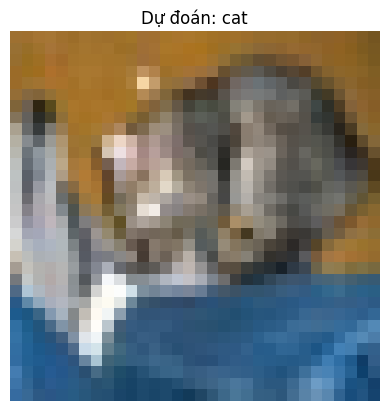

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Input
import matplotlib.pyplot as plt

# Tải bộ dữ liệu CIFAR-10 có sẵn trong Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Khai báo dictionary các nhãn theo đúng yêu cầu đề bài
class_names = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

print("Kích thước X_train ban đầu:", X_train.shape)

# Chuẩn hóa giá trị pixel về khoảng [0, 1] để mô hình dễ học
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Chuyển nhãn (y) sang dạng One-hot encoding
num_classes = 10
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes)

#xay dung mo hinh
model = Sequential()
model.add(Input(shape=(32, 32, 3)))

# Lớp Tích chập 1 & Gộp 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Lớp Tích chập 2 & Gộp 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Làm phẳng đặc trưng và đưa vào mạng nơ-ron dày đặc (Dense)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax')) # Output 10 class

model.summary()

#training
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Bắt đầu dạy học sinh
history = model.fit(X_train, y_train_one_hot, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

# Đánh giá trên tập test
score = model.evaluate(X_test, y_test_one_hot, verbose=0)
print('Độ chính xác trên tập Test (Test accuracy):', score[1])

# Lấy thử ảnh đầu tiên trong tập Test để dự đoán
test_image_index = 0
image = X_test[test_image_index]
true_label_index = y_test[test_image_index][0]

# Dự đoán
predict = model.predict(X_test[test_image_index : test_image_index+1])
predicted_label_index = np.argmax(predict)

print(f"\nMô hình dự đoán đây là: {class_names[predicted_label_index]}")
print(f"Nhãn thực tế là: {class_names[true_label_index]}")

# Vẽ ảnh ra để kiểm chứng trực quan
plt.imshow(image)
plt.title(f"Dự đoán: {class_names[predicted_label_index]}")
plt.axis('off')
plt.show()

#**Bài tập 2**

In [4]:
!unzip -q dataset.zip

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from keras.layers import Rescaling
from keras.layers import Input, RandomFlip, RandomRotation, RandomZoom, Dropout
import matplotlib.pyplot as plt

train_dir = '/content/training'
test_dir = '/content/test'

#đọc tập Train
train_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(150, 150),
    batch_size=32
)

#đọc tập Test
val_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(150, 150),
    batch_size=32
)

#tạo bộ lọc tự động xào nấu hình ảnh
data_augmentation = keras.Sequential(
  [
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
  ]
)

#xay dung mo hinh
model = Sequential([
    Input(shape=(150, 150, 3)),
    data_augmentation,
    Rescaling(1./255),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPool2D(),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPool2D(),
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

#bắt đầu huấn luyện
epochs = 10
history = model.fit(
  train_dataset,
  validation_data=val_dataset,
  epochs=epochs
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,049 (10.22 MB)

 Trainable params: 2,678,049 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.5864 - loss: 0.6688 - val_accuracy: 0.6678 - val_loss: 0.6172
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.6643 - loss: 0.6193 - val_accuracy: 0.7004 - val_loss: 0.5904
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.6752 - loss: 0.5982 - val_accuracy: 0.7163 - val_loss: 0.5630
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7067 - loss: 0.5758 - val_accuracy: 0.6990 - val_loss: 0.5786
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7109 - loss: 0.5683 - val_accuracy: 0.7405 - val_loss: 0.5380
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7233 - loss: 0.5450 - val_accuracy: 0.7266 - val_loss: 0.5433
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7429 - loss: 0.5191 - val_accuracy: 0.7360 - val_loss: 0.5392
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7520 - loss: 0.5056 - 

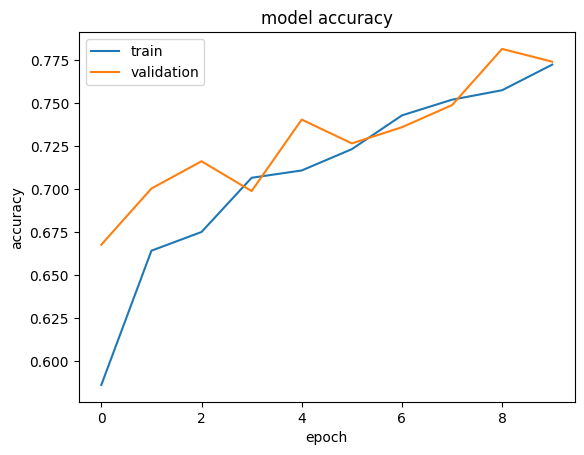

In [6]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [15]:
#dự đoán
class_names = ['cats', 'dogs']
img_path = '/content/cho1.jpg'
img = keras.utils.load_img(img_path, target_size=(150, 150))
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)
score = predictions[0]

if score[0] >= 0.5:
    print(f"Mô hình dự đoán đây là: {class_names[1]}, accuracy: {(score[0]) * 100:.2f}%")
else:
    print(f"Mô hình dự đoán đây là: {class_names[0]}, accuracy: {(1 - score[0]) * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Mô hình dự đoán đây là: dogs, accuracy: 97.80%


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
-> Ảnh 1 (meo.jpg): Chốt là CATS (59.04%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
-> Ảnh 2 (meo2.jpg): Chốt là CATS (52.55%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
-> Ảnh 3 (cho.jpg): Chốt là DOGS (99.86%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
-> Ảnh 4 (cho2.jpg): Chốt là DOGS (86.77%)


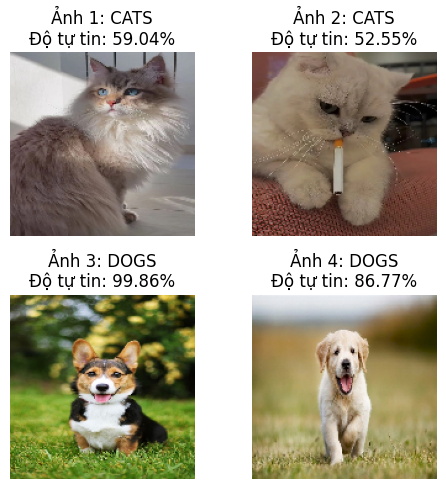

In [18]:
img_paths = [
    '/content/meo.jpg',
    '/content/meo2.jpg',
    '/content/cho.jpg',
    '/content/cho2.jpg'
]

plt.figure(figsize=(5, 5))

for i, img_path in enumerate(img_paths):
    try:
        img = keras.utils.load_img(img_path, target_size=(150, 150))
        img_array = keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        predictions = model.predict(img_array)
        score = predictions[0][0]
        if score >= 0.5:
            ket_luan = class_names[1].upper()
            do_tu_tin = score * 100
        else:
            ket_luan = class_names[0].upper()
            do_tu_tin = (1 - score) * 100
        plt.subplot(2, 2, i + 1)
        plt.imshow(img)
        plt.title(f"Ảnh {i+1}: {ket_luan}\nĐộ tự tin: {do_tu_tin:.2f}%", fontsize=12)
        plt.axis('off')
        print(f"-> Ảnh {i+1} ({img_path.split('/')[-1]}): Chốt là {ket_luan} ({do_tu_tin:.2f}%)")

    except Exception as e:
        print(f"Lỗi khi đọc ảnh {img_path}: Hãy kiểm tra lại tên file hoặc đường dẫn.")

plt.tight_layout()
plt.show()